In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
# load dataset
titanic = sns.load_dataset("titanic")

# features and target
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# ---------------------------
# handle missing data
# ---------------------------

# fill missing age with median
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# fill missing embarked with most frequent value
imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# ---------------------------
# encode categorical columns
# ---------------------------

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

# ---------------------------
# define X and y
# ---------------------------

X = titanic[features]
y = titanic[target]

In [3]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [4]:
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred_test=model.predict(X_test)
y_pred_train=model.predict(X_train)

print("training accuracy ",accuracy_score(y_train,y_pred_train)*100,"%")
print("testing accuracy ",accuracy_score(y_test,y_pred_test)*100,"%")

training accuracy  97.91332263242376 %
testing accuracy  76.49253731343283 %


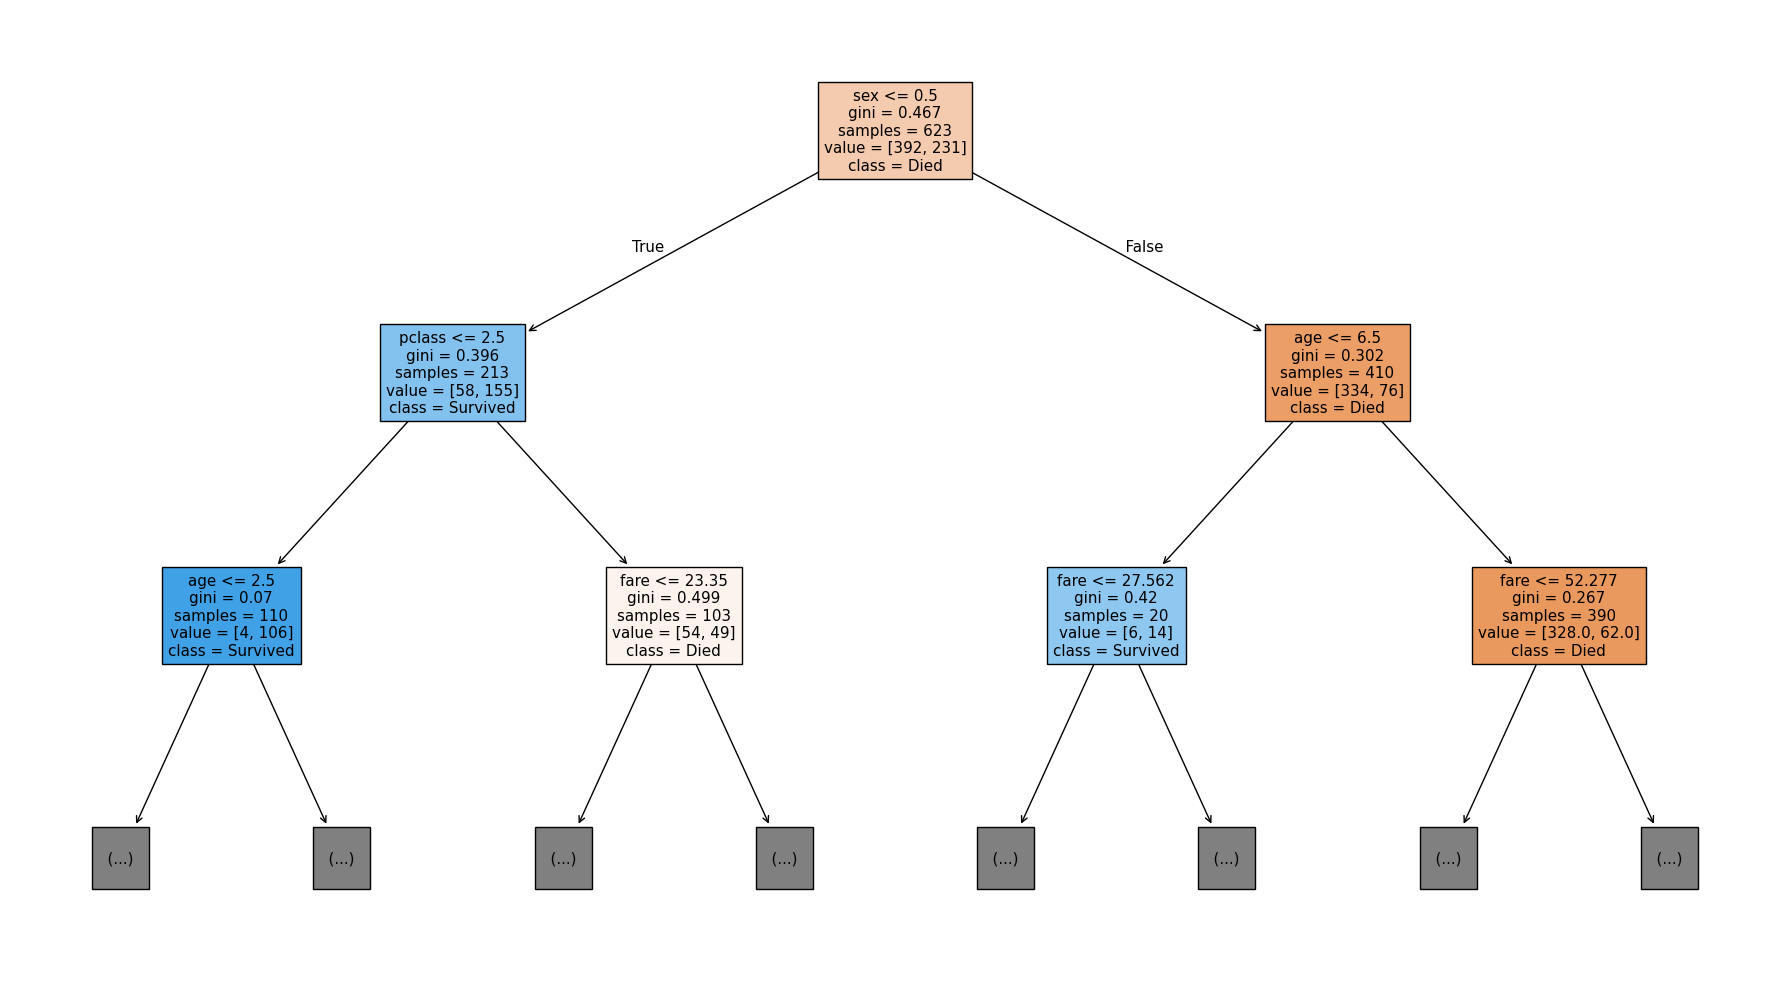

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()

In [6]:
#random forest 
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=201,
    oob_score=True
    
)
rf.fit(X_train,y_train)

y_pred= rf.predict(X_test)


print("testing accuracy ",accuracy_score(y_test,y_pred)*100,"%")
print("OOB Score : ",rf.oob_score_)

C:\Users\Rahul shakya\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


testing accuracy  77.98507462686567 %
OOB Score :  0.8073836276083467


In [7]:
#bagging classifier
from sklearn.ensemble import BaggingClassifier
base_model=model=DecisionTreeClassifier()

bagging=BaggingClassifier(
    base_model,
    n_estimators=201
)
model.fit(X_train,y_train)

y_pred_test =model.predict(X_test)
print("accuracy : ",accuracy_score(y_test,y_pred))

accuracy :  0.7798507462686567
